In [1]:
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.cm as cm
%config InlineBackend.figure_format = 'svg'

In [2]:
plt.rcParams.update({"font.size": 16})
plt.rcParams.update({"lines.linewidth": 2})

# EH Self Acceleration In Uniform Electric Field

In [3]:
L = 60 * np.pi
nx = 4000
dx = L / (nx - 1)

vmax_e = 10  # 速度最大值
nv_e = 2000
dv_e = 2 * vmax_e / (nv_e - 1)

vmax_i = 0.52185  # 速度最大值
nv_i = 2000
dv_i = 2 * vmax_i / (nv_i - 1)

x = np.linspace(0, L, num=nx, endpoint=True)
ve = np.linspace(-vmax_e, vmax_e, num=nv_e, endpoint=True)
vi = np.linspace(-vmax_i, vmax_i, num=nv_i, endpoint=True)
Ve, Xe = np.meshgrid(ve, x)
Vi, Xi = np.meshgrid(vi, x)

Ea_s = 5
Ea_e = 305

dt = 0.05
max_steps = 20000
data_steps = int(max_steps / 5)
data_num = int(max_steps / data_steps) + 1

# path = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\uniformE_E00004"
# path = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\uniformE_E00006"
path = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\uniformE_E00008"
# path = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\uniformE_E0001"
# path = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\uniformE_E00012"
# path = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\uniformE_E00014"

# path = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\uniformE_E00008_t105"
# path = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\uniformE_E00008_t205"
# path = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\uniformE_E00008_t405"
# path = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\uniformE_E00008_t505"

print(data_num)
print("real time = ", max_steps * dt)

6
real time =  1000.0


In [4]:
phi = np.loadtxt(os.path.join(path, "Phi_evolution"))
t = np.linspace(0, max_steps, num=max_steps + 1, endpoint=True) * dt

In [6]:
phi_peaks_x = np.argmax(phi, axis=0) * dx

v_fit_start = 12000
v_fit_end = 19001
phi_peaks_x_fit = phi_peaks_x[v_fit_start:v_fit_end]
t_fit = t[v_fit_start:v_fit_end]
velocity_fit, _ = np.polyfit(t_fit, phi_peaks_x_fit, 1)
print("Fitted velocity:", velocity_fit)

# fitting for the speed before the electric field is removed
v_fit2_start = 4000
v_fit2_end = 6001
phi_peaks_x_fit2 = phi_peaks_x[v_fit2_start:v_fit2_end]
t_fit2 = t[v_fit2_start:v_fit2_end]
velocity_fit2, _ = np.polyfit(t_fit2, phi_peaks_x_fit2, 1)
print("Fitted velocity2:", velocity_fit2)

Fitted velocity: 0.07795878757716923
Fitted velocity2: 0.03979443057594879


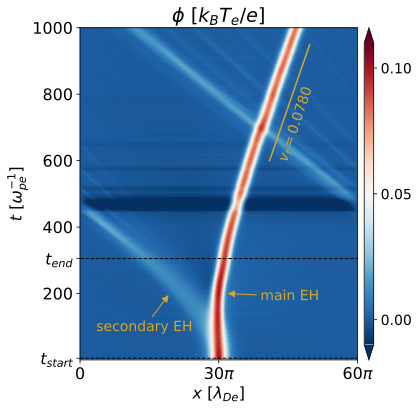

In [7]:
T, X = np.meshgrid(t, x)

fig = plt.figure(figsize=(6, 6))
cb = plt.pcolormesh(X, T, phi, vmin=-0.01, vmax=0.11, cmap=cm.RdBu_r, rasterized=True)
plt.plot(
    velocity_fit * t_fit + 82,
    t_fit,
    color="goldenrod",
    linestyle="-",
    linewidth=1.5,
    label="Fitted line",
)
plt.text(
    velocity_fit * t_fit[0] + 87,
    t_fit[0],
    r"$v_{f} = $" + f"{velocity_fit:.4f}",
    color="goldenrod",
    fontsize=14,
    rotation=71.3,
)

plt.axhline(y=Ea_s, color="black", linestyle="--", linewidth=1)
plt.axhline(y=Ea_e, color="black", linestyle="--", linewidth=1)
plt.annotate(
    "main EH",
    xy=(99, 200),
    xytext=(122.5, 180),
    arrowprops=dict(arrowstyle="-|>", facecolor="goldenrod", edgecolor="goldenrod"),
    fontsize=14,
    color="goldenrod",
)

plt.annotate(
    "secondary EH",
    xy=(61, 200),
    xytext=(11, 87),
    arrowprops=dict(arrowstyle="-|>", facecolor="goldenrod", edgecolor="goldenrod"),
    fontsize=14,
    color="goldenrod",
)

plt.xlabel(r"$x~[\lambda_{De}]$")
plt.ylabel(r"$t~[\omega_{pe}^{-1}]$")
plt.xticks([0, 30 * np.pi, 60 * np.pi], ["0", r"$30\pi$", r"$60\pi$"])
plt.yticks(
    [Ea_s, 200, Ea_e, 400, 600, 800, 1000],
    [r"$t_{start}$", r"$200$", r"$t_{end}$", r"$400$", r"$600$", r"$800$", r"$1000$"],
)
cbar = plt.colorbar(cb, ticks=[0.0, 0.05, 0.1], extend="both", aspect=35, pad=0.02)
cbar.ax.tick_params(labelsize=14)

plt.title(r"$\phi~[k_B T_e/e]$")
# plt.savefig("./fig3_phi_evo_uniformE00008.pdf", bbox_inches='tight', dpi = 600)
plt.show()

In [8]:
print(phi_peaks_x_fit[0], phi_peaks_x_fit[-1], t_fit[0], t_fit[-1])
print((phi_peaks_x_fit[-1] - phi_peaks_x_fit[0]) / (t_fit[-1] - t_fit[0]))

115.76521466191345 142.96249839966754 600.0 950.0
0.0777065249650117
